# biexciton model with cavity coupling (mediated by dark states)

### Accessible states
Custom Hilbert space for a cavity coupling with excitons: {|g>,|H>,|C>,|L>,|HH>,|HC>,|CC>,|LL>} with g: ground, H: heavy exciton, C: cavity photon, L: light exciton.

In [18]:
import matplotlib.pyplot as plt

# -*- coding: utf-8 -*-
"""
Created on Thu June 10 10:xx:xx 2026

@author: felix
"""

import sys
from time import gmtime, strftime

from qutip import *
import numpy as np
from qudpy.Classes import *
import qudpy.plot_functions as pf
import ufss
import matplotlib.animation as animation
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import axes3d
import pickle

np.set_printoptions(threshold=sys.maxsize, linewidth=190, precision=5, suppress=True)

plt.style.use('dark_background')

hbar = 0.658211951  # in eV fs
kB = 8.617333262 * 1e-5  # Boltzmann constant eV/K
T = 300  # temperature in K
kT = T * kB
beta = 1 / kT

### parameters

In [1]:
scale = 45

en_exc=1.4907 # excitonic resonant energy in eV
detuning = -0.005 # detuning between exciton and cavity in eV
en_cav=en_exc + detuning # cavity resonant energy in eV

N=2 # number of lattice sites
M=3 # number of fock basis for cavity mode. # maybe -> Use larger value for stronger couplings

rabi=0.04 # vaccum rabi splitting
g=rabi/2 # coupling strength for light-matter interaction in eV
J=0.01 # coupling strength between heavy and light excitons (from small band gap energy difference)
n_th=0.1 # average number thermal photons in the bath coupling to the resonator

muc=1.0 # dipole strength for cavity photons
muh=1.0 # dipole strength for heavy excitons
mul=0.0 # dipole strength for light excitons

mu_qm1=0.3 # dipole strength for H
mu_l1=0.04 # dipole strength for L
mu_l2=0.25 # dipole strength for LL

kappa=0.025 # cavity decay strength
gamma_h_decay=0.01 # heavy exciton decay strength
gamma_l_decay=0.002 # light exciton decay strength
gamma_cav_phase=0.01 # cavity dephasing strength
gamma_exc_phase=0.01 # exciton dephasing strength
gamma_hl=0.1 # exciton species swapping strength

ll_bind=0.5 # strength of neighboring LL binding

dark="k" # "light" if light exciton has no allowed transition from perturbation. anything other than those to use h_str and l_str
if dark == "light":
    mul = 0
model="rw" # "no_rw" for no rotating wave approximation, "rw" for rotating wave approximation

time2=120 # population time delay
directory="results/exc-exc_paper_model/" # result directory
anim="no" # animate # would make a gif if it didnt take 10mins per spectra

# 1 exciton maximum
#### essentially N=inf because of translation symmetry

In [20]:
if N == 1:

    # setting up dm
    exc_basis0 = np.zeros((4, 4));
    exc_basis0[0, 0] = 1;
    exc_basis = Qobj(exc_basis0)  # ground,1h,1c,1l
    rho = exc_basis * exc_basis.dag()  # ground state of Hamiltonian

    wc = en_cav / hbar
    wz = en_exc / hbar  # atom resonant frequencies

    # each individual lowering operators
    # each individual lowering operators
    h_low = np.zeros_like(exc_basis0);
    h_low[0, 1] = 1;
    h_low = Qobj(h_low)

    c_low = np.zeros_like(exc_basis0);
    c_low[0, 2] = 1;
    c_low = Qobj(c_low)

    l_low = np.zeros_like(exc_basis0);
    l_low[0, 3] = 1;
    l_low = Qobj(l_low)

    exc_h_low = h_low
    exc_l_low = l_low
    exc_low = exc_h_low + exc_l_low


    H_cav = hbar * (wz * h_low.dag() * h_low +
                    wc * c_low.dag() * c_low +
                    wz * l_low.dag() * l_low) # energes

    H_coupling = h_low.dag() * l_low  # H-L coupling
    H_coupling += H_coupling.dag()

    if model == "no-rw":
        H_int = hbar * (c_low + c_low.dag()) * (muh * (h_low.dag() + h_low) + mul * (l_low.dag() + l_low))
    elif model == "rw":
        H_int = hbar * (c_low.dag() * (muh * h_low + mul * l_low) + c_low * (muh * h_low.dag() + mul * l_low.dag()))
    else: print('Wrong model name')

# 2 lattice sites


In [21]:
if N == 2:

    # setting up dm
    exc_basis0 = np.zeros((8, 8));
    exc_basis0[0, 0] = 1;
    exc_basis = Qobj(exc_basis0)  # ground,1H,1C,1L,2H,HC,2C,2L-bound
    rho = exc_basis * exc_basis.dag()  # ground state of Hamiltonian

    wc = en_cav / hbar
    wz = en_exc / hbar  # atom resonant frequencies

    # each individual lowering operators
    h_low = np.zeros_like(exc_basis0);
    h_low[0, 1] = 1;
    h_low = Qobj(h_low)

    c_low = np.zeros_like(exc_basis0);
    c_low[0, 2] = 1;
    c_low = Qobj(c_low)

    l_low = np.zeros_like(exc_basis0);
    l_low[0, 3] = 1;
    l_low = Qobj(l_low)

    hh_low = np.zeros_like(exc_basis0);
    hh_low[1, 4] = 1;
    hh_low = Qobj(hh_low)

    hc_low = np.zeros_like(exc_basis0);
    hc_low[2, 5] = 1 / np.sqrt(2);
    hc_low = Qobj(hc_low)

    ch_low = np.zeros_like(exc_basis0);
    ch_low[1, 5] = 1 / np.sqrt(2);
    ch_low = Qobj(ch_low)

    cc_low = np.zeros_like(exc_basis0);
    cc_low[2, 6] = 1;
    cc_low = Qobj(cc_low)

    ll_low = np.zeros_like(exc_basis0);
    ll_low[3, 7] = 1;
    ll_low = Qobj(ll_low)

    # global lowering operators
    cav_low = c_low + ch_low + cc_low
    exc_h_low = h_low + hh_low + hc_low
    exc_l_low = l_low + ll_low

    H0_h = h_low.dag() * h_low # h-pop
    H0_c = c_low.dag() * c_low # c-pop
    H0_l = l_low.dag() * l_low # l-pop
    H0_hh = hh_low.dag() * hh_low # hh-pop
    H0_hc = hc_low.dag() * hc_low + ch_low.dag() * ch_low # hc-pop
    H0_cc = cc_low.dag() * cc_low # cc-pop
    H0_ll = ll_low.dag() * ll_low # ll-biexc-pop

    H0 = hbar * (wz * (H0_h + H0_l) + wc * H0_c + 2 * wz * H0_hh + 2 * wc * H0_cc + (wz + wc) * H0_hc + (2 * wz - ll_bind ) * H0_ll)

    H_coupling = h_low.dag() * l_low  # H-L coupling. 1 exciton states
    H_coupling += np.sqrt(2) * hh_low.dag() * h_low.dag() * l_low * ll_low # HH-LL coupling. 2 exciton states
    H_coupling += H_coupling.dag()

    if model == "no-rw":
        H_int = muh * (h_low.dag() * cav_low + 2 * (hh_low.dag() * ch_low + hc_low.dag() * cc_low) + h_low * ch_low + c_low * hc_low) + mul * cav_low.dag() * l_low
    elif model == "rw":
        H_int = muh * (h_low.dag() * cav_low + 2 * (hh_low.dag() * ch_low + hc_low.dag() * cc_low)) + mul * cav_low.dag() * l_low
    else: print('Wrong model name')
    H_int += H_int.dag()
    # print(H_int)

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.      0.      0.      0.      0.      0.      0.      0.     ]
 [0.      0.      1.      0.      0.      0.      0.      0.     ]
 [0.      1.      0.      0.1     0.      0.      0.      0.     ]
 [0.      0.      0.      0.      0.      0.      0.      0.     ]
 [0.      0.      0.      0.      0.      0.      0.      0.     ]
 [0.70711 0.      0.      0.      0.      0.      0.      0.     ]
 [0.      0.      0.      0.      0.      0.      0.      0.     ]
 [0.      0.      0.      0.      0.      0.      0.      0.     ]]


# Hamiltonian, dipole op., lowering op., collapse ops.
*H_0* is the energy of each state

*H_int* is the photon(cavity)-exciton(matter) interaction coupling with factor *g* strength.

*H_coupling* is the heavy exciton-light exciton coupling with factor *J* strength. Only states with the same number of excitons and a single different exciton species will couple.
###
*mud* is the dipole operator with the cavity lowering + raising and exciton lowering + raising operators.

*ad* is the total lowering operator for the perturbation to impact the system.
###
*c_cav_rel* and *c_cav_exc* are the Lindblad cavity relaxation/excitation operators.

*c_col_dep* is the Lindblad collective dephasing operator which acts on the exciton populations.

*c_mat_rel* and *c_mat_exc* are the Lindblad cavity matter relaxation/excitation operators.

*c_h_l* and *c_l_h* are the Lindblad heavy→light and light→heavy exciton transition operators.

*c_swap* is the Lindblad exciton→neighboring empty lattice site transition operator.

In [22]:
H = H0 + g * H_int + J * H_coupling  # total hamiltonian
# print("H0", H0)
# print("H_int", H_int)
# print("H_coupling", H_coupling)
print("H", H)

mud = muc * (c_low + c_low.dag()) + muh * (exc_h_low + exc_h_low.dag()) + mul * (exc_l_low + exc_l_low.dag()) # dipole operator
ad =  muc * cav_low + muh * exc_h_low + mul * exc_l_low # lowering operator
# print("mud", mud)
# print("ad", ad)

# collapse operators
c_cav_rel = np.sqrt(kappa * (n_th + 1)) * cav_low # cavity relaxation
c_cav_exc = np.sqrt(kappa * n_th) * cav_low.dag() # cavity excitation
c_dep = (np.sqrt(gamma_exc_phase) * wz * (H0_h + H0_l) +
        np.sqrt(gamma_cav_phase) * wz * H0_c +
        np.sqrt(gamma_exc_phase) * 2 * wz * H0_hh +
        np.sqrt(gamma_cav_phase) * 2 * wc * H0_cc +
         (np.sqrt(gamma_cav_phase) + np.sqrt(gamma_exc_phase)) / 2 * (wz + wc) * H0_hc +
        np.sqrt(gamma_exc_phase) * (2 * wz - ll_bind ) * H0_ll) # exciton dephasing
c_mat_rel = np.sqrt(gamma_h_decay * (n_th + 1)) * exc_h_low + np.sqrt(gamma_l_decay * (n_th + 1)) * exc_l_low # collective exciton relaxation
c_mat_exc = np.sqrt(gamma_h_decay * n_th) * exc_h_low.dag() + np.sqrt(gamma_l_decay * n_th) * exc_l_low.dag() # collective exciton excitation
c_h_l = np.sqrt(gamma_hl * n_th) * exc_l_low.dag() * exc_h_low # heavy exciton to light exciton transition
c_l_h = np.sqrt(gamma_hl * (n_th + 1)) * exc_h_low.dag() * exc_l_low # light exciton to heavy exciton transition
c_ops = [c_cav_rel, c_cav_exc, c_dep, c_mat_rel, c_mat_exc, c_h_l, c_l_h]

H Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.      0.      0.      0.      0.      0.      0.      0.     ]
 [0.      1.4907  0.05    0.05    0.      0.      0.      0.     ]
 [0.      0.05    1.3907  0.005   0.      0.      0.      0.     ]
 [0.      0.05    0.      1.4907  0.      0.      0.      0.     ]
 [0.      0.      0.      0.      2.9814  0.      0.      0.07071]
 [0.03536 0.      0.      0.      0.      2.8814  0.      0.     ]
 [0.      0.      0.      0.      0.      0.      2.7814  0.     ]
 [0.      0.      0.      0.      0.07071 0.      0.      2.91558]]


### Initializing the system

In [23]:
print("dimensionality of Hilbert-space: ", H.shape)

# setting up system
syst = System(H=H, rho=rho, a=ad, u=mud, c_ops=c_ops, diagonalize=True)

en, T = H.eigenstates()
print("eigenenergies", en)
# print("eigenstates", T)

print("system has been intialized")

# # calculate the expectation value of the number of photons in the cavity
# n_vec = expect(a.dag() * a, rho)
# # print("expectation of number of photons: ", n_vec)
# n2_vec = expect(a.dag() * a*a.dag() * a, rho)
# a_vec = expect(a, rho)

# graph_title = f"{time.localtime().tm_hour:02d}:{time.localtime().tm_min:02d}_N{N}_M{M}_g{g}_J{J}_k{kappa}_gph{gamma_phase}_gdc{gamma_decay}_ghl{gamma_hl}"
time = strftime("%Hh%M", gmtime())
graph_title = time+f"_N{N}_M{M}_g{g:.3f}_J{J:.3f}_detun{detuning:.4f}_gph-cx{gamma_cav_phase:.3f}-{gamma_exc_phase:.3f}_gdc-chl{kappa:.3f}-{gamma_h_decay:.3f}-{gamma_l_decay:.3f}_ghl{gamma_hl:.3f}_"+model
# print(graph_title)

dimensionality of Hilbert-space:  (8, 8)
diagonalizing Hamiltonian and transforming everything into eigen-basis except rho
system initialized
eigenenergies [0.     +0.j 1.36741+0.j 1.45475+0.j 1.54993+0.j 2.7814 +0.j 2.8705 +0.j 2.8814 +0.j 3.02648+0.j]
system has been intialized


### Linear spectra + pickle saving

  0%|          | 0/999 [00:00<?, ?it/s]

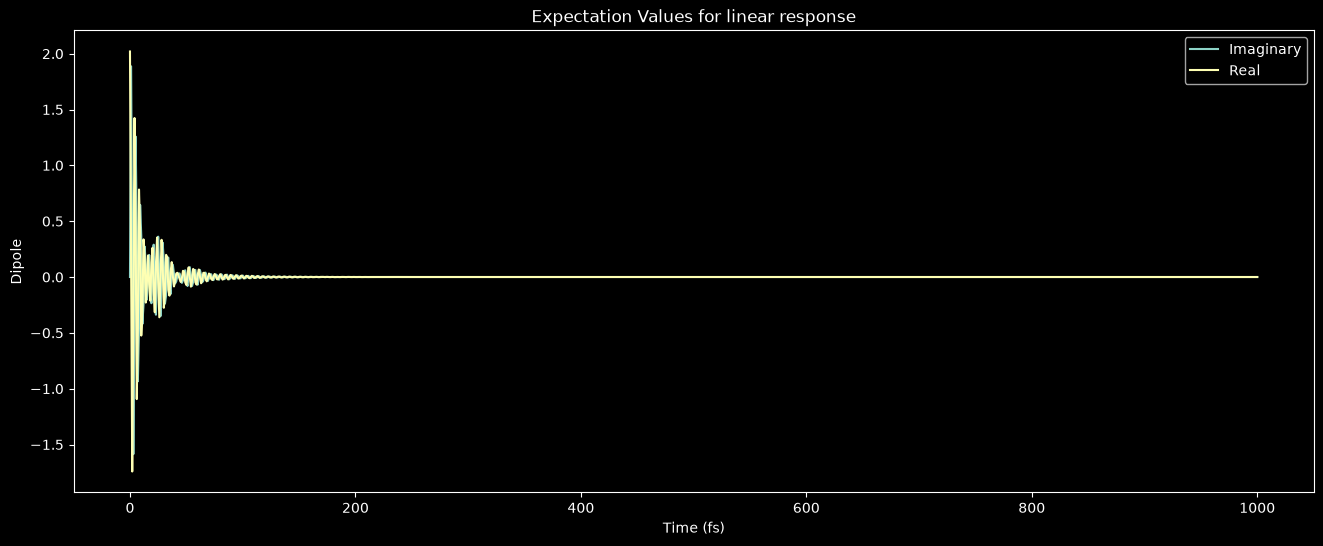

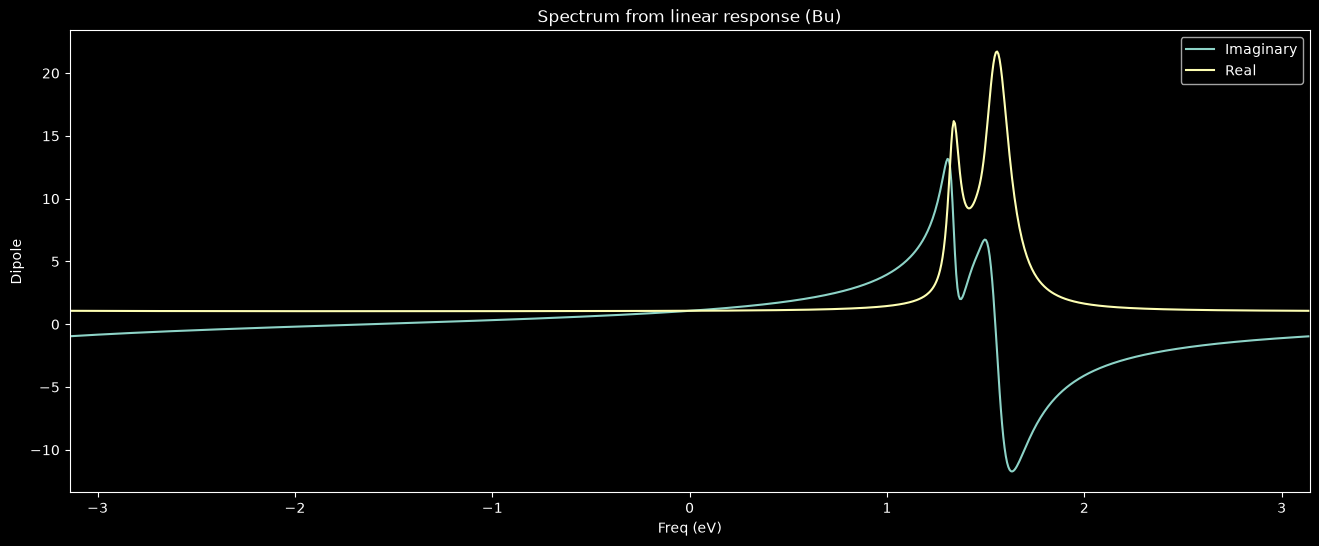

In [24]:
d0 = 2000

dipole, t_list, spec, freq = syst.linear_spec(d0, r=1, dir=directory, title_graph="lindip_"+graph_title)

os.makedirs("results/exc-exc_paper_data/"+graph_title, exist_ok=True)
with open("results/exc-exc_paper_data/"+graph_title+"/dip.pkl", "wb") as file:
    pickle.dump(dipole, file)
with open("results/exc-exc_paper_data/"+graph_title+"/tlist.pkl", "wb") as file:
    pickle.dump(t_list, file)
with open("results/exc-exc_paper_data/"+graph_title+"/spec.pkl", "wb") as file:
    pickle.dump(spec, file)
with open("results/exc-exc_paper_data/"+graph_title+"/freq.pkl", "wb") as file:
    pickle.dump(freq, file)

#### pickle loading

In [25]:
# with open("results/exc-exc_paper_data/"+graph_title+"/dip.pkl", "rb") as file:
#     dipole = pickle.load(file)
# with open("results/exc-exc_paper_data/"+graph_title+"/tlist.pkl", "rb") as file:
#     t_list = pickle.load(file)
# with open("results/exc-exc_paper_data/"+graph_title+"/spec.pkl", "rb") as file:
#     spec = pickle.load(file)
# with open("results/exc-exc_paper_data/"+graph_title+"/freq.pkl", "rb") as file:
#     freq = pickle.load(file)

### Linear plotting

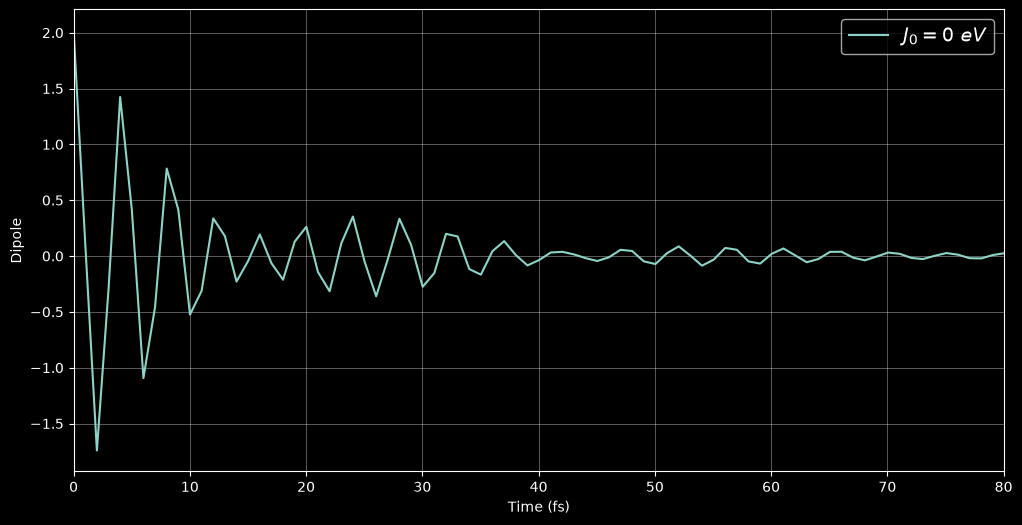

C:\Users\felix\PycharmProjects\QuDPy\.venv\Lib\site-packages\matplotlib\cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


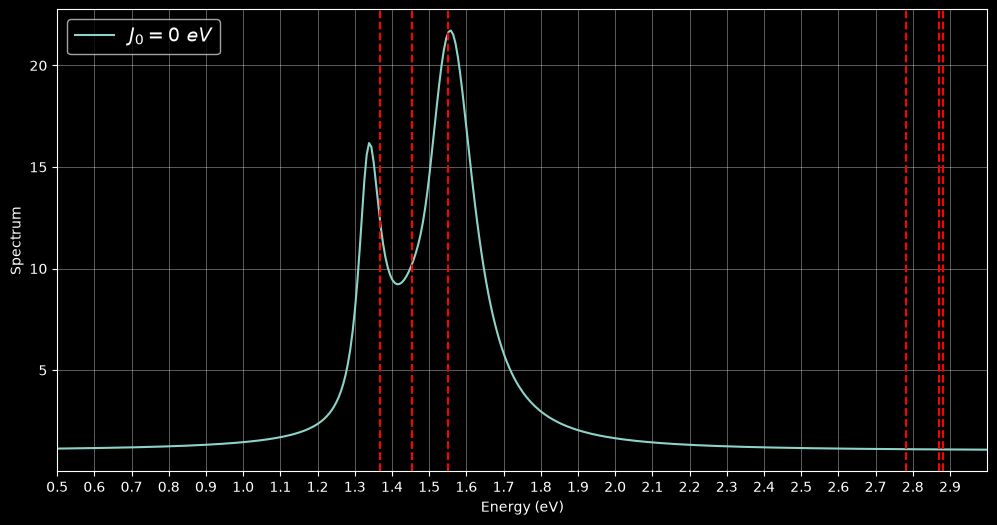

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(t_list, np.real(dipole), label="$J_{0} = 0 \\ eV$")  # real part of the dipole
plt.xlim(0, 80)
plt.xlabel("Time (fs)")
plt.ylabel("Dipole")
plt.legend(fontsize=14)
plt.grid()
plt.close()

plt.figure(figsize=(12, 6))
plt.plot(freq, np.real(spec), label="$J_{0} = 0 \\ eV$")  # real part of the spectrum
plt.xlim(0.5, 3.0)
plt.xticks(np.arange(0.5, 3.0, 0.1))
for i in H.eigenenergies():
    plt.axvline(x=i, color='red', linestyle='--')
plt.xlabel("Energy (eV)")
plt.ylabel("Spectrum")
plt.legend(fontsize=14)
plt.grid()
plt.savefig(directory+"linspec_"+graph_title+".png")
plt.show()

### 3rd order spectra + pickle saving
For time delays, it seems you need at least as many as 1/(weakest coupling) to see the specific features. Weaker couplings means bigger time delays aka longer simulation run time.

In [ ]:
# Setting up the required double sided diagrams for tests
# DiagramGenerator class, or DG for short
DG = ufss.DiagramGenerator
# initialize the module

R3rd = DG()  # DG takes a single key-word argument, which has the default value detection_type = 'polarization'
# DiagramAutomation needs to know the phase-matching/-cycling condition
R3rd.set_phase_discrimination([(0, 1), (1, 0), (1, 0)])  # setting phase-matching condition for rephasing diagrams R1,2,3
# Set the pulse interval
t_pulse = np.array([-1, 1])
R3rd.efield_times = [t_pulse] * 4

# Creating diagrams for pulse arrival times 0, 120, 240 and detection time 360.
[R3, R1, R2] = R3rd.get_diagrams([0, 120, 240, 360])
rephasing = [R1, R2, R3]
print('the rephasing diagrams are R1, R2 and R3 ', rephasing)

# setting conditions for and generating non-rephasing diagrams R4, R5 and R6
R3rd.set_phase_discrimination([(1, 0), (0, 1), (1, 0)])
[R6, R4, R5] = R3rd.get_diagrams([0, 120, 240, 240])
nonrephasing = [R4, R5, R6]
print('the non-rephasing diagrams are R4, R5 and R6', nonrephasing)

# syst.diagram_donkey([0, 120, 120+time2, 240+time2], [R3], r=10, title_graph=None, plot_graph=False, dir=directory)

print("finished setup stage")

# generating 2Dcoherence response for rephasing diagrams
time_delays = [200, 20, 200]
scan_id = [0, 2]
response_list = []
diagrams = rephasing + nonrephasing
for k in range(6):
    states, t1, t2, dipole = syst.coherence2d(time_delays, diagrams[k], scan_id, r=1, parallel=True)
    print('diagram ', k, ' done')
    response_list.append(1j * dipole)
spectra_list, extent, f1, f2 = syst.spectra(np.imag(response_list), resolution=1)

with open("results/exc-exc_paper_data/"+graph_title+"/spec2d.pkl", "wb") as file:
    pickle.dump(spectra_list, file)
with open("results/exc-exc_paper_data/"+graph_title+"/extent.pkl", "wb") as file:
    pickle.dump(extent, file)
with open("results/exc-exc_paper_data/"+graph_title+"/f1.pkl", "wb") as file:
    pickle.dump(f1, file)
with open("results/exc-exc_paper_data/"+graph_title+"/f2.pkl", "wb") as file:
    pickle.dump(f2, file)

the rephasing diagrams are R1, R2 and R3  [(('Bu', 0), ('Ku', 1), ('Bd', 2)), (('Bu', 0), ('Bd', 1), ('Ku', 2)), (('Bu', 0), ('Ku', 1), ('Ku', 2))]
the non-rephasing diagrams are R4, R5 and R6 [(('Ku', 0), ('Bu', 1), ('Ku', 2)), (('Ku', 0), ('Bu', 1), ('Bd', 2)), (('Ku', 0), ('Kd', 1), ('Ku', 2))]
finished setup stage
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors


#### pickle loading

In [ ]:
# with open("results/exc-exc_paper_data/"+graph_title+"/spec2d.pkl", "rb") as file:
#     spec2d = pickle.load(file)
# with open("results/exc-exc_paper_data/"+graph_title+"/extent.pkl", "rb") as file:
#     extent = pickle.load(file)
# with open("results/exc-exc_paper_data/"+graph_title+"/f1.pkl", "rb") as file:
#     f1 = pickle.load(file)
# with open("results/exc-exc_paper_data/"+graph_title+"/f2.pkl", "rb") as file:
#     f2 = pickle.load(file)

#### 3rd order plotting

In [ ]:
rephasing_spectra = spectra_list[:3]
rephasing_spectra.append(np.sum(spectra_list[:3], 0))
pf.silva_plot_contourf(rephasing_spectra, f1, f2, labels=['E emission', 'E absorption'],
          scale='linear', color_map='PuOr', title_list = ['$R_1$', '$R_2$', '$R_3$', '$R_{rephasing}$'],
          center_scale=False, plot_sum=False, plot_quadrant='Zoom', zoom_coor=[-2,-0.8,0.8,2],
          invert_y=False, diagonals=[True, False], nlevels=15,
          title_graph=graph_title, plot_graph=True, direc=directory)